# Сравнение ARIMA, GRU и LSTM на данных о климате Дели




In [34]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (12, 4)

# Загрузка и очистка данных

In [35]:
train = pd.read_csv("DailyDelhiClimateTrain.csv", parse_dates=["date"], index_col="date")
test = pd.read_csv("DailyDelhiClimateTest.csv", parse_dates=["date"], index_col="date")

# дата 2017-01-01 есть и в конце train (строка-заглушка: влажность 100, ветер 0), и в начале test.
# Оставляем строку из test, дубликат убираем из train
dup = train.index.isin(test.index)
print("Дубликатов дат train/test:", dup.sum())
train = train[~dup]

FEATURES = ["meantemp", "humidity", "wind_speed", "meanpressure"]
n_train = len(train)

print("train:", train.shape, train.index.min().date(), "->", train.index.max().date())
print("test: ", test.shape, test.index.min().date(), "->", test.index.max().date())
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Пропуски:", train.isna().sum().sum(), test.isna().sum().sum())
train.describe()

Дубликатов дат train/test: 1
train: (1461, 4) 2013-01-01 -> 2016-12-31
test:  (114, 4) 2017-01-01 -> 2017-04-24
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Пропуски: 0 0


,meantemp,humidity,wind_speed,meanpressure
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,25.506127,60.744851,6.806865,1011.101197
std,7.339416,16.743928,4.559688,180.293335
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.571429
50%,27.714286,62.625000,6.250000,1008.555556
75%,31.312500,72.125000,9.250000,1014.937500
max,38.714286,98.000000,42.220000,7679.333333


Выбросов давления: 10


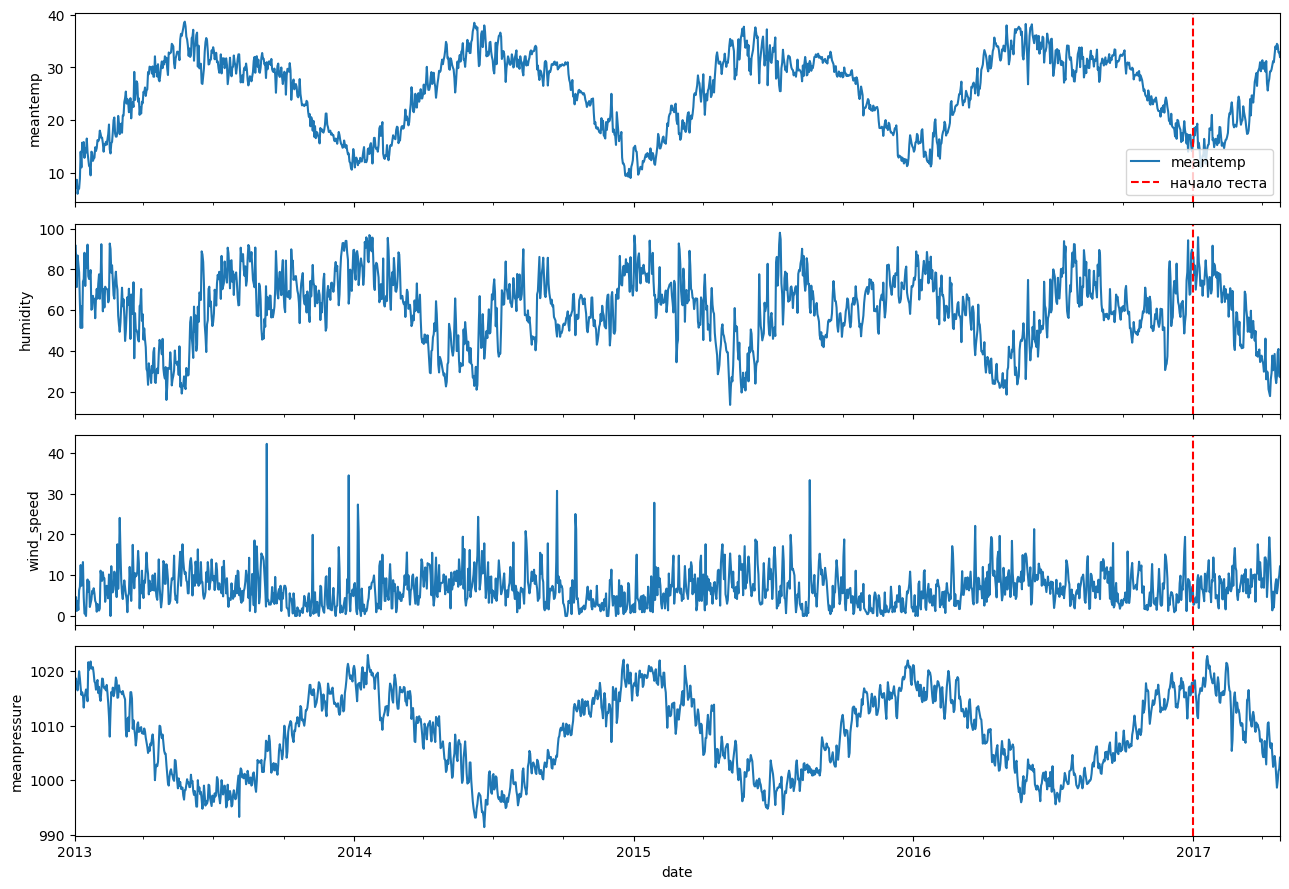

In [36]:
df = pd.concat([train, test])[FEATURES].copy()
assert df.index.is_unique
df = df.asfreq("D")                                 # ровная дневная сетка (пропуски, если есть, станут NaN)

bad = (df["meanpressure"] < 980) | (df["meanpressure"] > 1050)
print("Выбросов давления:", bad.sum())
df.loc[bad, "meanpressure"] = np.nan
df = df.interpolate(method="linear").bfill()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, col in zip(axes, FEATURES):
    df[col].plot(ax=ax)
    ax.axvline(test.index.min(), color="red", ls="--", label="начало теста")
    ax.set_ylabel(col)
axes[0].legend()
plt.tight_layout()
plt.show()

# Подготовка данных

In [39]:
LOOKBACK = 30     
VAL_FRAC = 0.1     

# масштабирование: scaler обучаем только на train
scaler = MinMaxScaler()
scaler.fit(df.iloc[:n_train])
scaled = scaler.transform(df)                       # (n, 4)
scaled_df = pd.DataFrame(scaled, index=df.index, columns=FEATURES)

def make_windows(arr, target_idx, lookback):
    """X[i] = arr[i : i+lookback, :] (все 4 ряда), y[i] = arr[i+lookback, target_idx]."""
    X, y = [], []
    for i in range(len(arr) - lookback):
        X.append(arr[i:i + lookback])
        y.append(arr[i + lookback, target_idx])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

def inverse_target(values, target_idx):
    """Обратное MinMax-преобразование для одного столбца."""
    return (np.asarray(values).ravel() - scaler.min_[target_idx]) / scaler.scale_[target_idx]

def evaluate(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

# тестовые даты
test_idx = df.index[n_train:]
print("Тестовых точек:", len(test_idx))

Тестовых точек: 114


# Модели

### 1 ARIMAX
Для каждого целевого ряда:
1. порядок `d` выбирается по тесту Дики–Фуллера;
2. `p`, `q` подбираются по AIC на train (небольшая сетка);
3. остальные 3 ряда подаются как экзогенные регрессоры **со сдвигом на 1 день** (чтобы не использовать будущую информацию);
4. параметры фиксируются по train, а прогноз на тесте строится one-step-ahead .

In [41]:
from statsmodels.tsa.stattools import adfuller, kpss

def choose_d(s, max_d=2, alpha=0.05):
    for d in range(max_d + 1):
        x = s.diff(d).dropna() if d else s
        adf_p = adfuller(x, autolag="AIC")[1]
        kpss_p = kpss(x, nlags="auto")[1]
        if adf_p < alpha and kpss_p >= alpha:   # стационарен по обоим тестам
            return d, adf_p, kpss_p
    return max_d, adf_p, kpss_p

D, rows = {}, []
for target in FEATURES:
    s = scaled_df[target].iloc[:n_train]
    d, adf_p, kpss_p = choose_d(s)
    D[target] = d
    rows.append({"target": target, "d": d, "ADF p": adf_p, "KPSS p": kpss_p})

display(pd.DataFrame(rows).set_index("target").round(3))
print("D =", D)

,d,ADF p,KPSS p
target,,,
meantemp,1,0.000,0.1
humidity,0,0.004,0.1
wind_speed,0,0.002,0.1
meanpressure,1,0.000,0.1


D = {'meantemp': 1, 'humidity': 0, 'wind_speed': 0, 'meanpressure': 1}


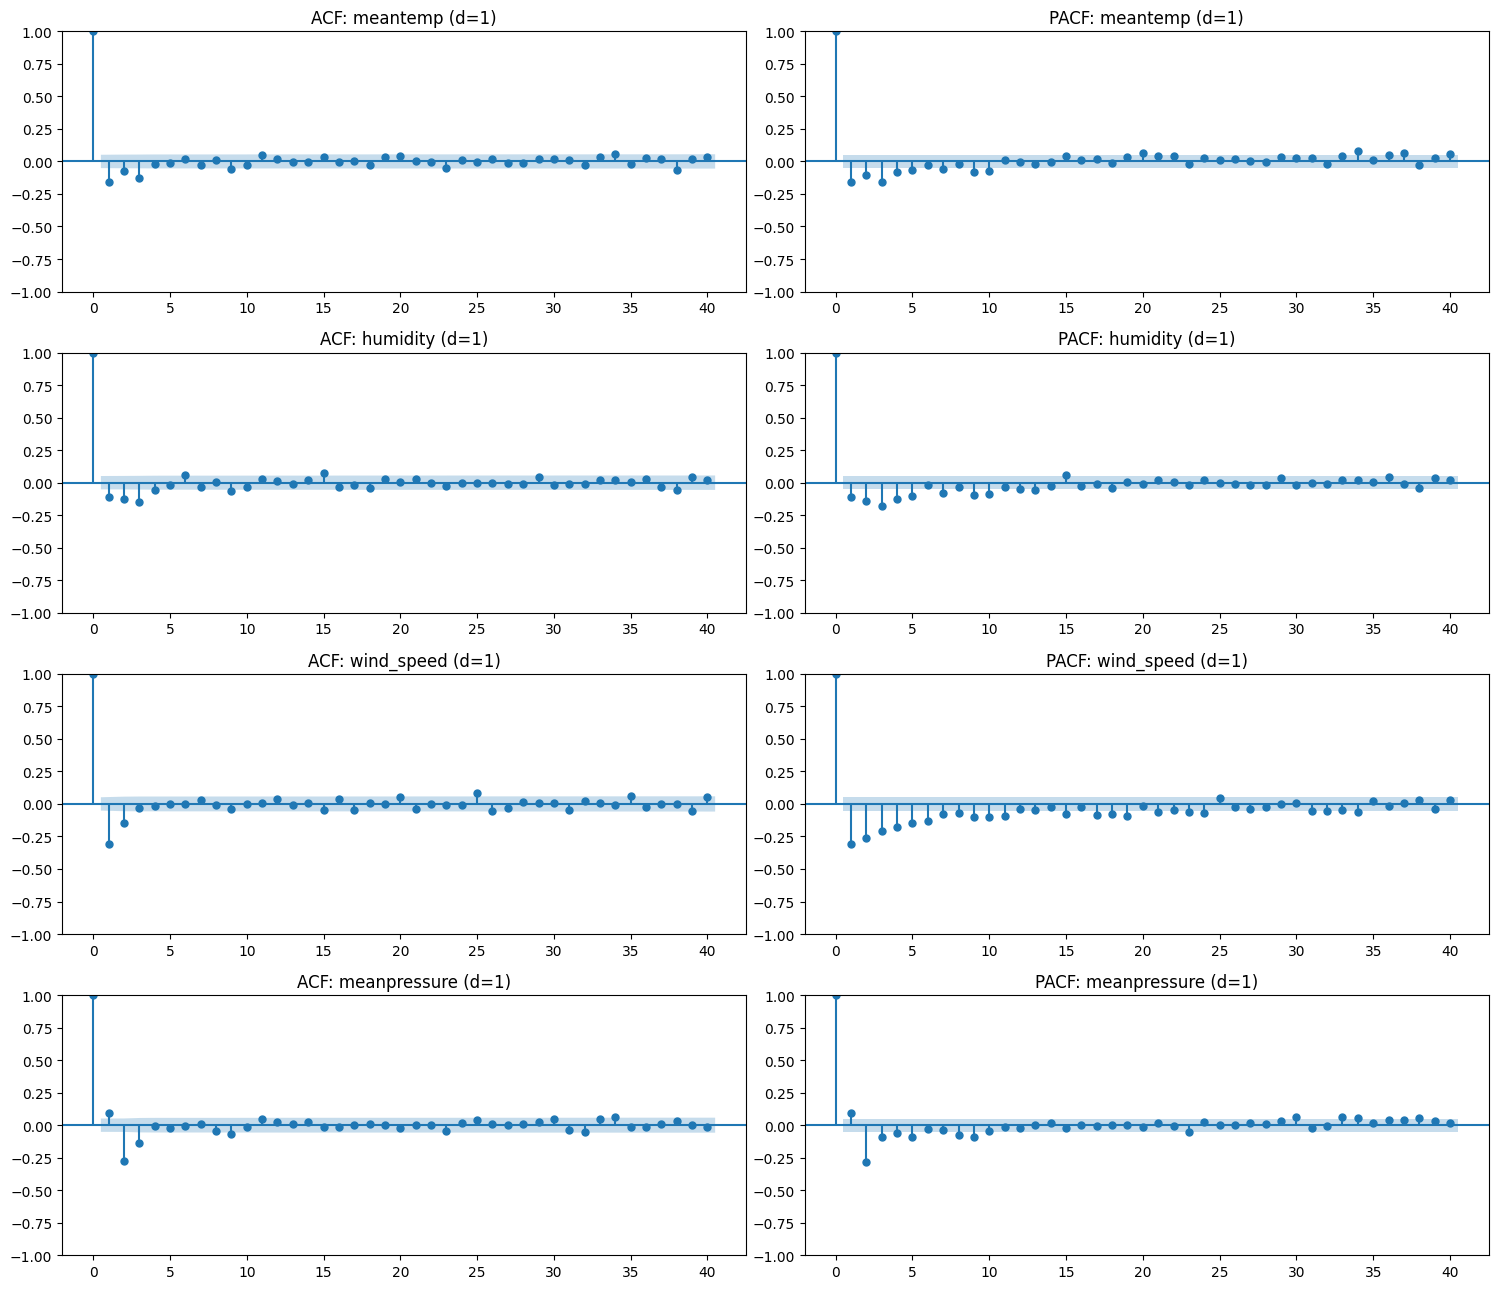

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

D = {"meantemp": 1, "humidity": 1, "wind_speed": 1, "meanpressure": 1}   
LAGS = 40

fig, axes = plt.subplots(4, 2, figsize=(15, 13))
for i, target in enumerate(FEATURES):
    s = scaled_df[target].iloc[:n_train]
    if D[target] > 0:
        s = s.diff(D[target]).dropna()
    plot_acf(s, lags=LAGS, ax=axes[i, 0], title=f"ACF: {target} (d={D[target]})")
    plot_pacf(s, lags=LAGS, ax=axes[i, 1], method="ywm", title=f"PACF: {target} (d={D[target]})")
plt.tight_layout()
plt.show()

In [48]:
ORDERS = {                      #p d q
    "meantemp":     (5, 1, 3),
    "humidity":     (5, 1, 3),
    "wind_speed":   (7, 1, 2),
    "meanpressure": (5, 1, 3),
}

def fit_arimax(target_idx, order):
    target = FEATURES[target_idx]
    others = [f for f in FEATURES if f != target]

    endog = scaled_df[target]
    exog = scaled_df[others].shift(1)               
    endog, exog = endog.iloc[1:], exog.iloc[1:]
    n_tr = n_train - 1

    res = SARIMAX(endog.iloc[:n_tr], exog=exog.iloc[:n_tr], order=order,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False, maxiter=200)
    print(f"{target:13s} ARIMAX order={order}, AIC={res.aic:.1f}")

    # one-step-ahead на всём ряду с фиксированными параметрами
    res_full = res.apply(endog=endog, exog=exog)
    pred_scaled = res_full.fittedvalues.loc[test_idx]
    return inverse_target(pred_scaled.values, target_idx), order

### 2 GRU и LSTM

In [50]:
EPOCHS = 80
BATCH = 32

def build_rnn(cell, n_features=len(FEATURES)):
    model = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_features)),
        layers.RNN(cell(64)),                      
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def fit_rnn(cell, name, target_idx):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    X, y = make_windows(scaled, target_idx, LOOKBACK)
    n_fit = n_train - LOOKBACK                      
    X_tr_all, y_tr_all = X[:n_fit], y[:n_fit]
    X_te = X[n_fit:]                                

    n_val = int(len(X_tr_all) * VAL_FRAC)
    X_tr, y_tr = X_tr_all[:-n_val], y_tr_all[:-n_val]
    X_val, y_val = X_tr_all[-n_val:], y_tr_all[-n_val:]

    model = build_rnn(cell)
    es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
    print(f"{FEATURES[target_idx]:13s} {name}: эпох={len(hist.history['loss'])}, "
          f"best val_loss={min(hist.history['val_loss']):.5f}")

    pred = model.predict(X_te, verbose=0)
    return inverse_target(pred, target_idx), hist

# Обучение всех 12 моделей
Для каждого из 4 целевых рядов: ARIMAX, GRU, LSTM + наивный baseline (значение предыдущего дня).

In [51]:
predictions = {}   # (target, model) -> np.array на тестовых датах
histories = {}     # (target, model) -> history
orders = {}
rows = []

for k, target in enumerate(FEATURES):
    y_true = df[target].iloc[n_train:].values

    # --- ARIMAX
    pred, order = fit_arimax(k, ORDERS[target])
    predictions[(target, "ARIMAX")] = pred
    orders[target] = order

    # --- GRU
    pred, h = fit_rnn(layers.GRUCell, "GRU", k)
    predictions[(target, "GRU")] = pred
    histories[(target, "GRU")] = h

    # --- LSTM
    pred, h = fit_rnn(layers.LSTMCell, "LSTM", k)
    predictions[(target, "LSTM")] = pred
    histories[(target, "LSTM")] = h

    # --- naive baseline: вчерашнее значение
    predictions[(target, "Naive")] = df[target].shift(1).iloc[n_train:].values

    for name in ["ARIMAX", "GRU", "LSTM", "Naive"]:
        m = evaluate(y_true, predictions[(target, name)])
        rows.append({"target": target, "model": name, **m})

results = pd.DataFrame(rows)
results

meantemp      ARIMAX order=(5, 1, 3), AIC=-4653.7
meantemp      GRU: эпох=22, best val_loss=0.00155
meantemp      LSTM: эпох=11, best val_loss=0.00202
humidity      ARIMAX order=(5, 1, 3), AIC=-2818.9
humidity      GRU: эпох=54, best val_loss=0.00703
humidity      LSTM: эпох=69, best val_loss=0.00727
wind_speed    ARIMAX order=(7, 1, 2), AIC=-2704.6
wind_speed    GRU: эпох=61, best val_loss=0.00641
wind_speed    LSTM: эпох=55, best val_loss=0.00672
meanpressure  ARIMAX order=(5, 1, 3), AIC=-4621.5
meanpressure  GRU: эпох=27, best val_loss=0.00227
meanpressure  LSTM: эпох=27, best val_loss=0.00323


,target,model,RMSE,MAE,R2
0,meantemp,ARIMAX,1.670130,1.328226,0.930433
1,meantemp,GRU,1.969129,1.618008,0.903295
2,meantemp,LSTM,3.087654,2.462624,0.762229
3,meantemp,Naive,1.684436,1.313624,0.929236
4,humidity,ARIMAX,6.768538,5.356566,0.872883
5,humidity,GRU,7.141336,5.508416,0.858495
6,humidity,LSTM,7.232655,5.695511,0.854853
7,humidity,Naive,7.409646,5.850469,0.847662
8,wind_speed,ARIMAX,3.233056,2.534053,0.180901
9,wind_speed,GRU,3.277107,2.576862,0.158429


# Сравнение моделей

In [52]:
MODELS = ["ARIMAX", "GRU", "LSTM", "Naive"]

for metric in ["RMSE", "MAE", "R2"]:
    print(f"\n=== {metric} ===")
    display(results.pivot(index="target", columns="model", values=metric)
            .loc[FEATURES, MODELS].round(4))


=== RMSE ===


model,ARIMAX,GRU,LSTM,Naive
target,,,,
meantemp,1.6701,1.9691,3.0877,1.6844
humidity,6.7685,7.1413,7.2327,7.4096
wind_speed,3.2331,3.2771,3.1596,3.7323
meanpressure,1.7604,1.9415,2.3627,1.9223



=== MAE ===


model,ARIMAX,GRU,LSTM,Naive
target,,,,
meantemp,1.3282,1.6180,2.4626,1.3136
humidity,5.3566,5.5084,5.6955,5.8505
wind_speed,2.5341,2.5769,2.4811,3.0240
meanpressure,1.3619,1.4997,1.7224,1.4881



=== R2 ===


model,ARIMAX,GRU,LSTM,Naive
target,,,,
meantemp,0.9304,0.9033,0.7622,0.9292
humidity,0.8729,0.8585,0.8549,0.8477
wind_speed,0.1809,0.1584,0.2177,-0.0916
meanpressure,0.9039,0.8831,0.8268,0.8854


In [53]:
# RMSE, нормированный на std целевого ряда на тесте — сопоставимо между рядами
std_test = {t: df[t].iloc[n_train:].std() for t in FEATURES}
results["nRMSE"] = results.apply(lambda r: r["RMSE"] / std_test[r["target"]], axis=1)

nrmse = results.pivot(index="target", columns="model", values="nRMSE").loc[FEATURES, MODELS]
display(nrmse.round(3))

print("Средний nRMSE по моделям (меньше — лучше):")
print(nrmse.mean().sort_values().round(3))

print("\nЛучшая модель для каждого ряда (по RMSE, среди ARIMAX/GRU/LSTM):")
best = (results[results["model"] != "Naive"].sort_values("RMSE")
        .groupby("target").first().loc[FEATURES, ["model", "RMSE", "MAE", "R2"]])
display(best.round(4))

model,ARIMAX,GRU,LSTM,Naive
target,,,,
meantemp,0.263,0.310,0.485,0.265
humidity,0.355,0.375,0.379,0.389
wind_speed,0.901,0.913,0.881,1.040
meanpressure,0.309,0.340,0.414,0.337


Средний nRMSE по моделям (меньше — лучше):
model
ARIMAX    0.457
GRU       0.484
Naive     0.508
LSTM      0.540
dtype: float64

Лучшая модель для каждого ряда (по RMSE, среди ARIMAX/GRU/LSTM):


,model,RMSE,MAE,R2
target,,,,
meantemp,ARIMAX,1.6701,1.3282,0.9304
humidity,ARIMAX,6.7685,5.3566,0.8729
wind_speed,LSTM,3.1596,2.4811,0.2177
meanpressure,ARIMAX,1.7604,1.3619,0.9039


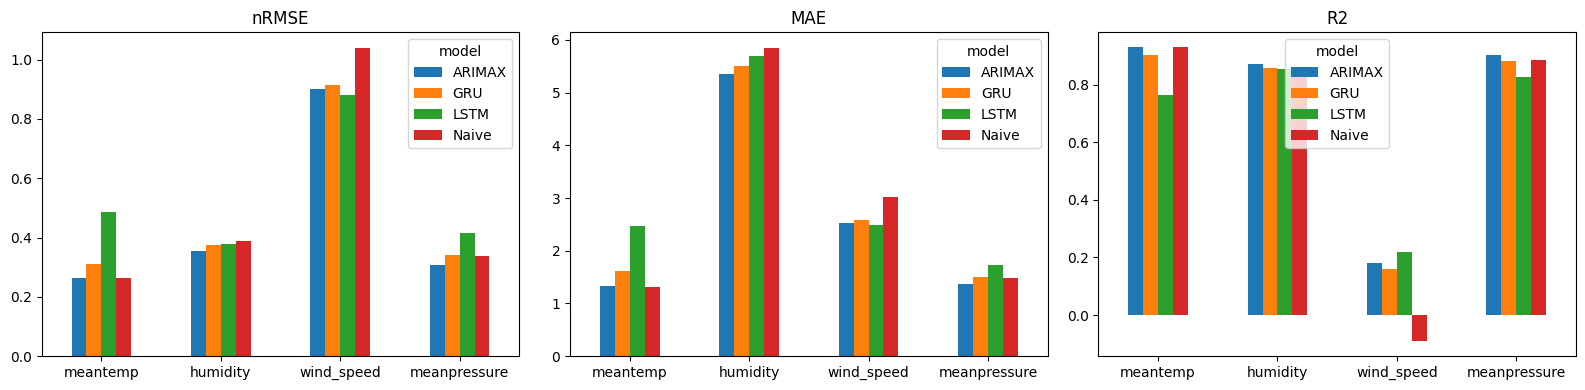

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["nRMSE", "MAE", "R2"]):
    pv = results.pivot(index="target", columns="model", values=metric).loc[FEATURES, MODELS]
    pv.plot.bar(ax=ax, rot=0)
    ax.set_title(metric)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

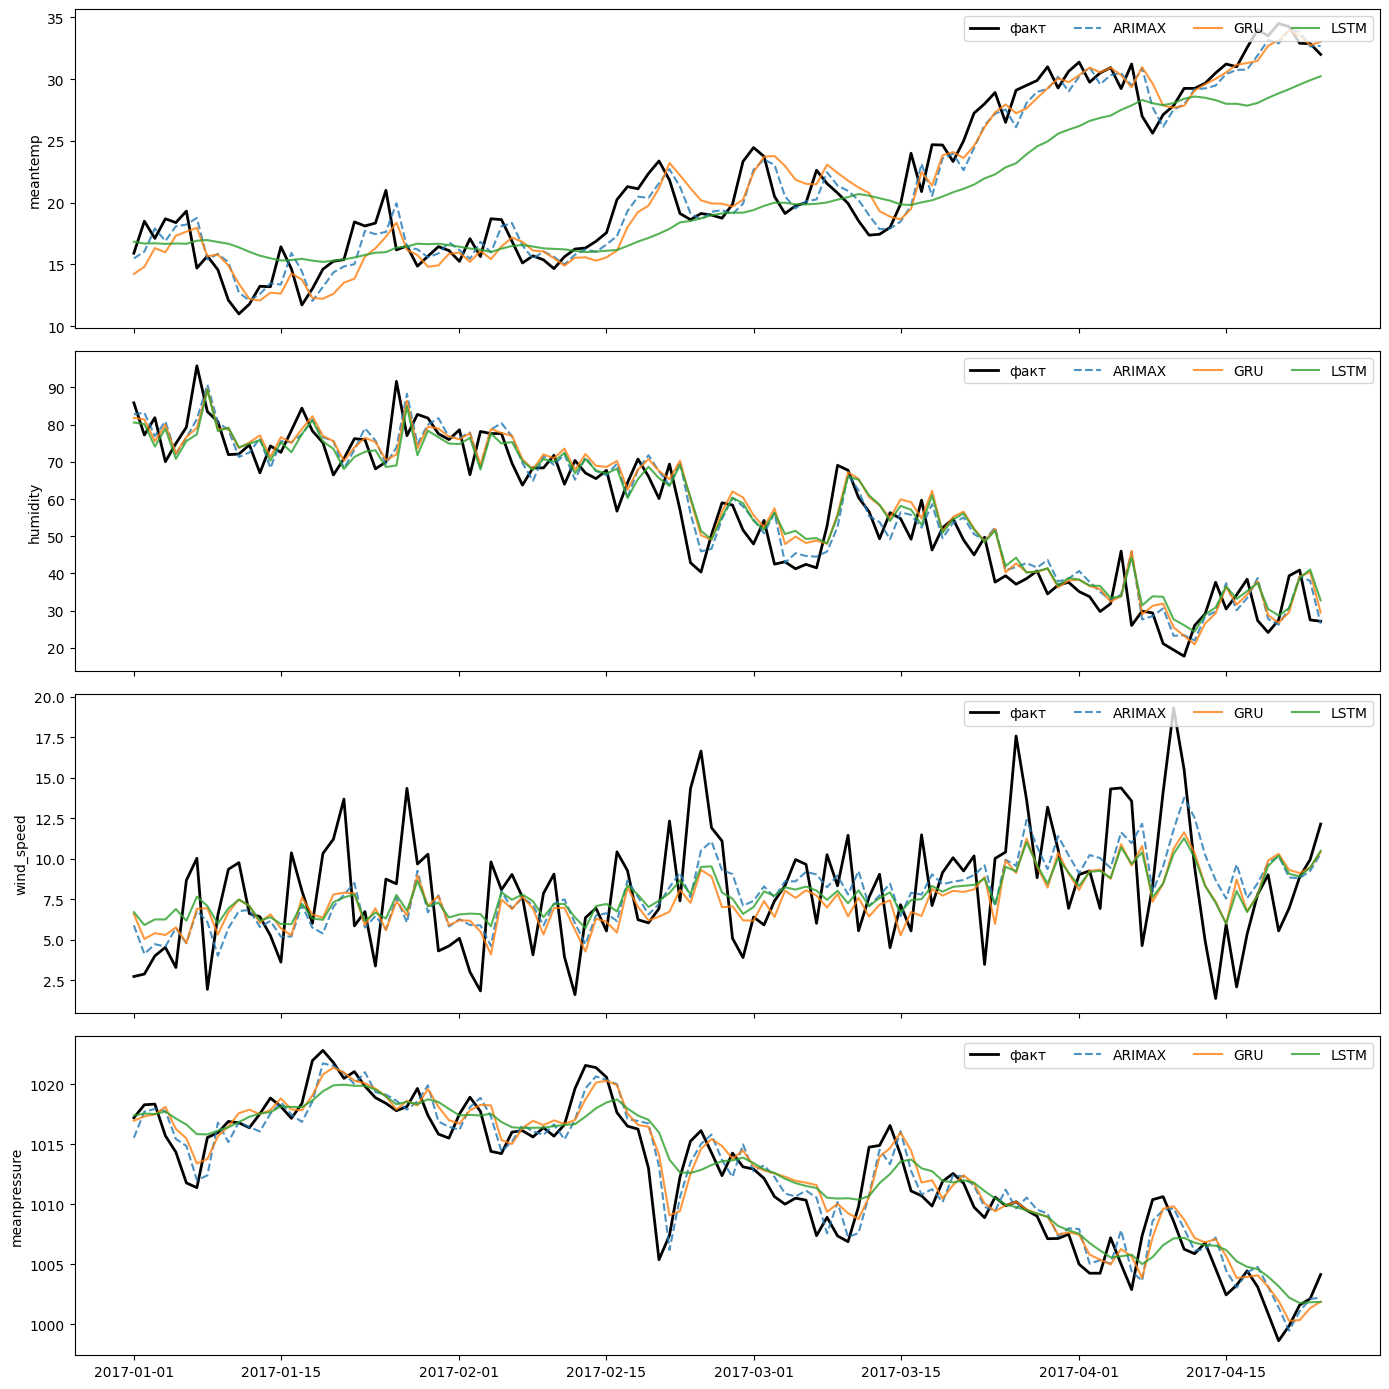

In [55]:
# прогнозы на тесте
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
for ax, target in zip(axes, FEATURES):
    ax.plot(test_idx, df[target].iloc[n_train:].values, "k", lw=2, label="факт")
    for name, style in [("ARIMAX", "--"), ("GRU", "-"), ("LSTM", "-")]:
        ax.plot(test_idx, predictions[(target, name)], style, alpha=0.8, label=name)
    ax.set_ylabel(target)
    ax.legend(loc="upper right", ncol=4)
plt.tight_layout()
plt.show()

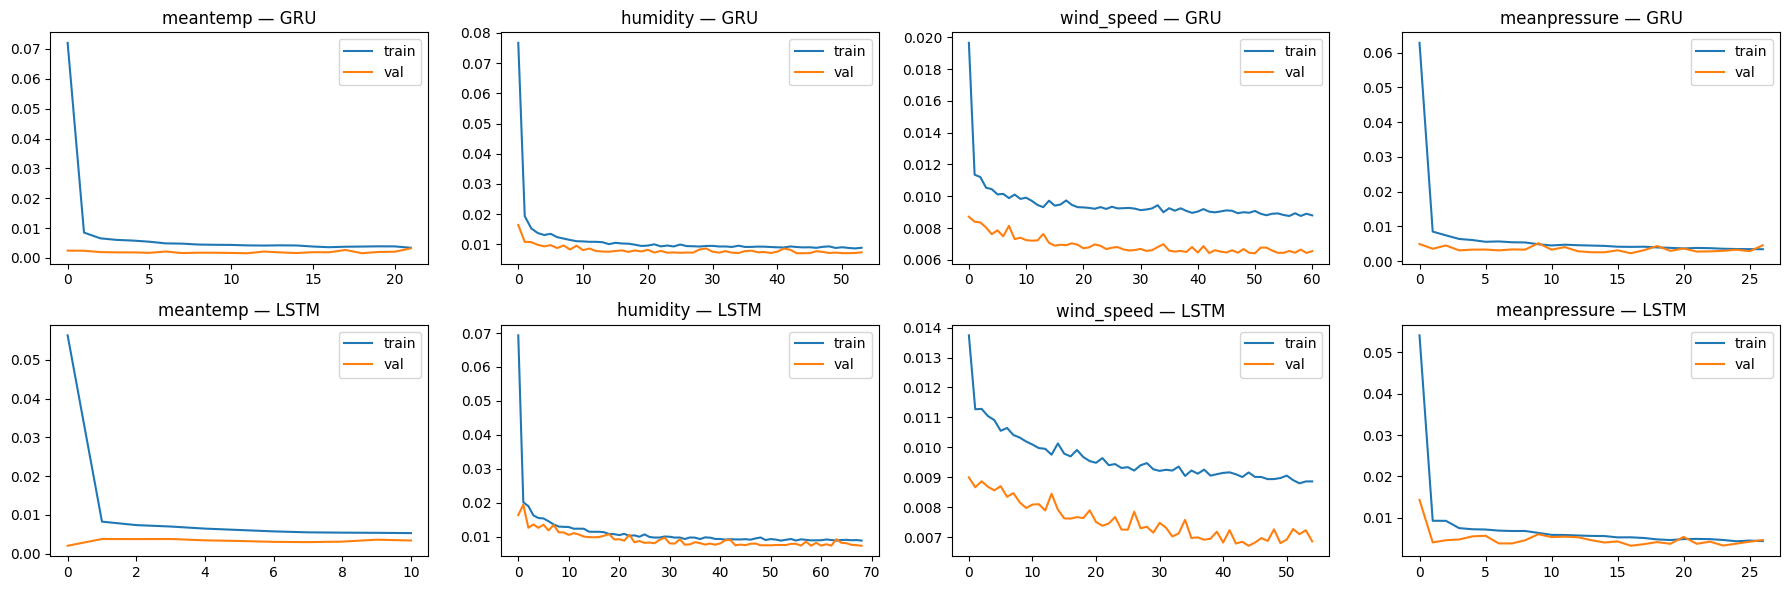

In [56]:
# кривые обучения нейросетей
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for j, target in enumerate(FEATURES):
    for i, name in enumerate(["GRU", "LSTM"]):
        h = histories[(target, name)].history
        axes[i, j].plot(h["loss"], label="train")
        axes[i, j].plot(h["val_loss"], label="val")
        axes[i, j].set_title(f"{target} — {name}")
        axes[i, j].legend()
plt.tight_layout()
plt.show()

# Прогноз на 7 дней вперед


In [ ]:
H = 7   

def make_windows_multi(arr, target_idx, lookback, horizon):
    X, Y = [], []
    for i in range(len(arr) - lookback - horizon + 1):
        X.append(arr[i:i + lookback])                                   
        Y.append(arr[i + lookback:i + lookback + horizon, target_idx])  
    return np.array(X, dtype="float32"), np.array(Y, dtype="float32")

def inverse_matrix(P, target_idx):
    return (P - scaler.min_[target_idx]) / scaler.scale_[target_idx]

n_test = len(test_idx)
n_win_test = n_test - H + 1        # число начал прогноза в тесте (дальше должны быть H дней факта)
print("Тестовых прогнозов (по H дней):", n_win_test)

Тестовых прогнозов (по H дней): 108


In [58]:
def build_rnn_multi(cell, horizon, n_features=len(FEATURES)):
    model = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_features)),
        layers.RNN(cell(64)),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(horizon),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def fit_rnn_multi(cell, name, target_idx):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    X, Y = make_windows_multi(scaled, target_idx, LOOKBACK, H)
    n_fit = n_train - LOOKBACK - H + 1            # окна, у которых ВСЕ H целей лежат в train
    X_tr_all, Y_tr_all = X[:n_fit], Y[:n_fit]
    X_te = X[n_train - LOOKBACK:]                 # окна, у которых первая цель - первый день теста

    n_val = int(len(X_tr_all) * VAL_FRAC)
    X_tr, Y_tr = X_tr_all[:-n_val], Y_tr_all[:-n_val]
    X_val, Y_val = X_tr_all[-n_val:], Y_tr_all[-n_val:]

    model = build_rnn_multi(cell, H)
    es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = model.fit(X_tr, Y_tr, validation_data=(X_val, Y_val),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
    print(f"{FEATURES[target_idx]:13s} {name}: эпох={len(hist.history['loss'])}, "
          f"best val_loss={min(hist.history['val_loss']):.5f}")

    pred = model.predict(X_te, verbose=0)         # (n_win_test, H)
    return inverse_matrix(pred, target_idx), hist

In [ ]:
def forecast_arimax_multi(target_idx, order):
    target = FEATURES[target_idx]
    others = [f for f in FEATURES if f != target]

    endog = scaled_df[target]
    exog = scaled_df[others].shift(1)
    endog, exog = endog.iloc[1:], exog.iloc[1:]
    n_tr = n_train - 1                             # позиция первого тестового дня в endog

    res = SARIMAX(endog.iloc[:n_tr], exog=exog.iloc[:n_tr], order=order,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False, maxiter=200)

    preds = []
    for j in range(n_win_test):
        t = n_tr + j                              
        res_t = res.apply(endog.iloc[:t], exog=exog.iloc[:t])      
        exog_fut = np.tile(exog.iloc[t].values, (H, 1))            
        fc = res_t.get_forecast(steps=H, exog=exog_fut).predicted_mean.values
        preds.append(fc)
    print(f"{target:13s} ARIMAX order={order}")
    return inverse_matrix(np.array(preds), target_idx)

In [60]:
def true_matrix(target):
    v = df[target].values
    return np.array([v[n_train + j: n_train + j + H] for j in range(n_win_test)])

def naive_matrix(target):
    v = df[target].values
    return np.array([np.repeat(v[n_train + j - 1], H) for j in range(n_win_test)])

pred_h, hist_h, rows_h = {}, {}, []

for k, target in enumerate(FEATURES):
    Y_true = true_matrix(target)

    pred_h[(target, "ARIMAX")] = forecast_arimax_multi(k, ORDERS[target])

    pred_h[(target, "GRU")], hist_h[(target, "GRU")] = fit_rnn_multi(layers.GRUCell, "GRU", k)
    pred_h[(target, "LSTM")], hist_h[(target, "LSTM")] = fit_rnn_multi(layers.LSTMCell, "LSTM", k)
    pred_h[(target, "Naive")] = naive_matrix(target)

    for name in ["ARIMAX", "GRU", "LSTM", "Naive"]:
        P = pred_h[(target, name)]
        for h in range(H):
            rows_h.append({"target": target, "model": name, "h": h + 1,
                           "RMSE": np.sqrt(mean_squared_error(Y_true[:, h], P[:, h])),
                           "MAE": mean_absolute_error(Y_true[:, h], P[:, h])})

res_h = pd.DataFrame(rows_h)
res_h.head()

meantemp      ARIMAX order=(5, 1, 3)
meantemp      GRU: эпох=16, best val_loss=0.00319
meantemp      LSTM: эпох=29, best val_loss=0.00385
humidity      ARIMAX order=(5, 1, 3)
humidity      GRU: эпох=31, best val_loss=0.01486
humidity      LSTM: эпох=32, best val_loss=0.01525
wind_speed    ARIMAX order=(7, 1, 2)
wind_speed    GRU: эпох=30, best val_loss=0.00894
wind_speed    LSTM: эпох=13, best val_loss=0.00913
meanpressure  ARIMAX order=(5, 1, 3)
meanpressure  GRU: эпох=20, best val_loss=0.00557
meanpressure  LSTM: эпох=20, best val_loss=0.00599


,target,model,h,RMSE,MAE
0,meantemp,ARIMAX,1,1.704641,1.364435
1,meantemp,ARIMAX,2,2.314213,1.897431
2,meantemp,ARIMAX,3,2.750625,2.335982
3,meantemp,ARIMAX,4,3.096709,2.609677
4,meantemp,ARIMAX,5,3.311339,2.738641


model,ARIMAX,GRU,LSTM,Naive
target,,,,
meantemp,2.895,2.857,2.837,2.935
humidity,9.396,8.679,8.863,9.908
wind_speed,3.607,3.530,4.024,4.805
meanpressure,3.250,3.171,2.988,3.585


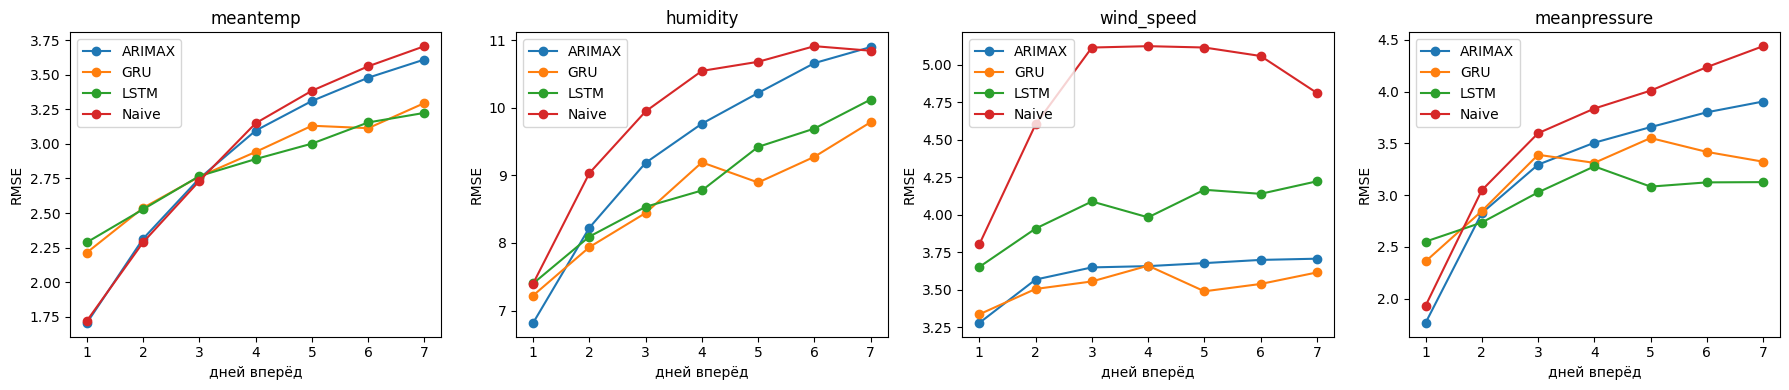

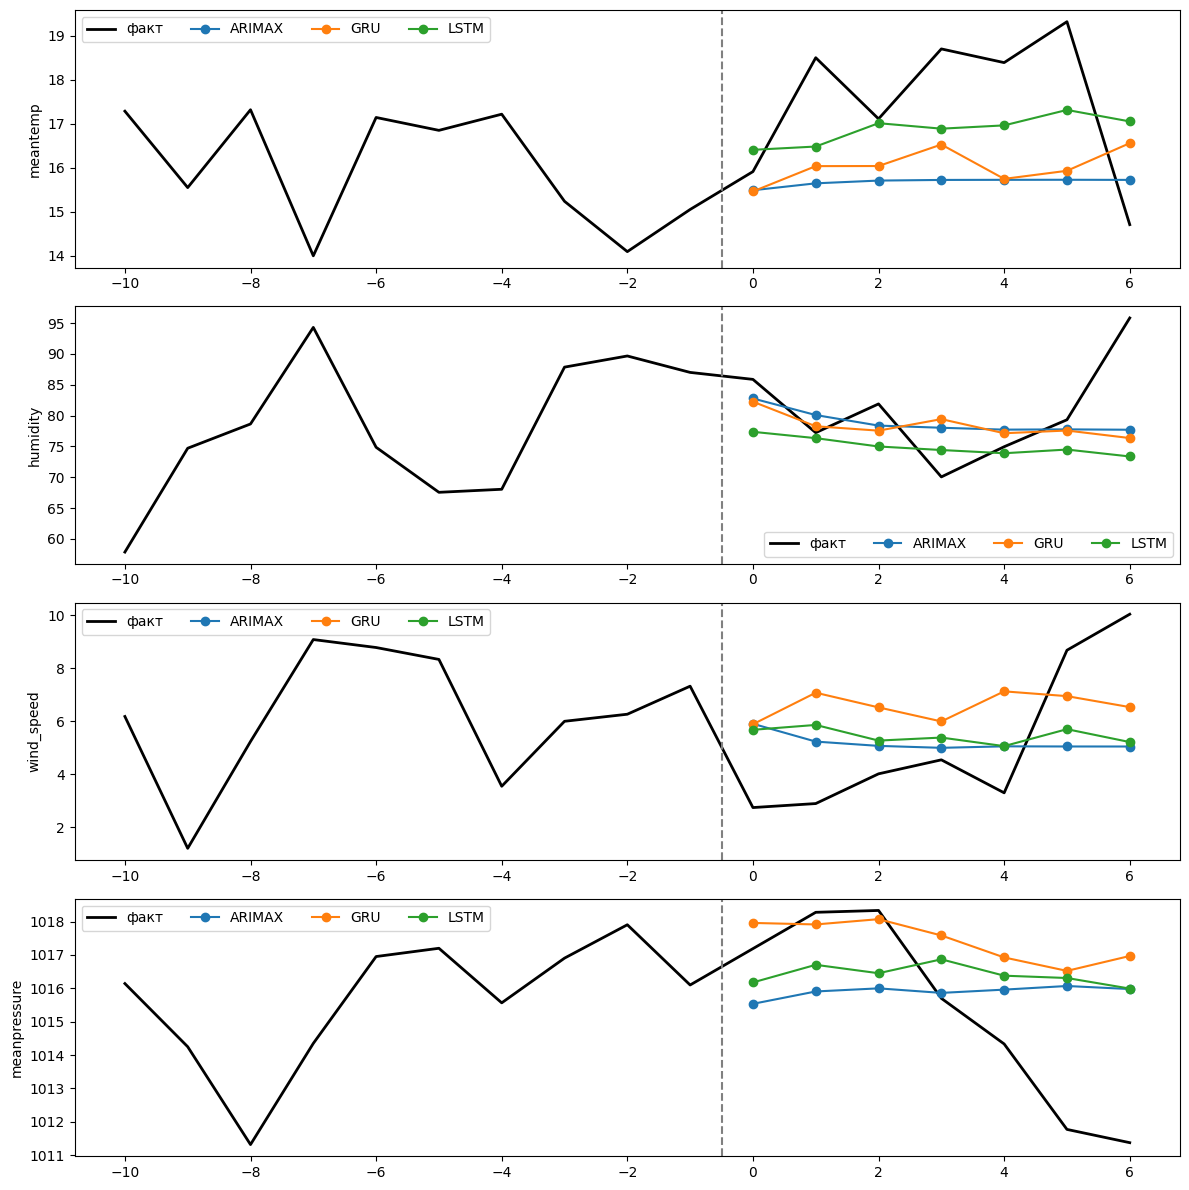

In [61]:
MODELS = ["ARIMAX", "GRU", "LSTM", "Naive"]

# средний RMSE по горизонту
mean_rmse = res_h.groupby(["target", "model"])["RMSE"].mean().unstack()[MODELS].loc[FEATURES]
display(mean_rmse.round(3))

# RMSE по дням горизонта
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, target in zip(axes, FEATURES):
    for name in MODELS:
        d = res_h[(res_h.target == target) & (res_h.model == name)]
        ax.plot(d["h"], d["RMSE"], marker="o", label=name)
    ax.set_title(target)
    ax.set_xlabel("дней вперёд")
    ax.set_ylabel("RMSE")
    ax.legend()
plt.tight_layout()
plt.show()

# пример прогноза: одно начало, все модели
j = 0
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
for ax, target in zip(axes, FEATURES):
    v = df[target].values
    ax.plot(range(-10, H), np.r_[v[n_train + j - 10: n_train + j], true_matrix(target)[j]], "k", lw=2, label="факт")
    for name in ["ARIMAX", "GRU", "LSTM"]:
        ax.plot(range(0, H), pred_h[(target, name)][j], marker="o", label=name)
    ax.axvline(-0.5, color="gray", ls="--")
    ax.set_ylabel(target)
    ax.legend(ncol=4)
plt.tight_layout()
plt.show()